# Set environment

In [1]:
### Basic
import numpy  as np
import scipy  as sc
import pandas as pd
import glob, os, re
import pickle, sys

### import flowImg
py_path = "/local_data/notebooks/clintko/GitRepo/Proj_Flow2Image"
sys.path.insert(0, py_path)
from flowImg import *

### sklearn
from sklearn.metrics import roc_curve, auc, accuracy_score

### plot
import matplotlib.pyplot as plt
plt.style.use("seaborn-whitegrid")

### global const
SEED    = 123
DAT_DIR = "/data/clintko/flow_EQAPOL_normal/mpsk"

/local_data/env-py3/lib/python3.6/site-packages/h5py/__init__.py:36: FutureWarning: Conversion of the second argument of issubdtype from `float` to `np.floating` is deprecated. In future, it will be treated as `np.float64 == np.dtype(float).type`.
  from ._conv import register_converters as _register_converters
Using TensorFlow backend.


# Load data

In [2]:
!ls /data/clintko/flow_EQAPOL_normal/mpsk

C_1e4.csv		   mpsk_1e4_costim_res.RDS  wrap02_tsne_1e4_N10.P
mpsk_1e4_cmv_cal.RDS	   mpsk_1e4_seb_cal.RDS     wrap03_img_1e4_var10.P
mpsk_1e4_cmv_chain.RDS	   mpsk_1e4_seb_chain.RDS   Y_1e4_cmv.csv
mpsk_1e4_cmv_res.RDS	   mpsk_1e4_seb_res.RDS     Y_1e4_costim.csv
mpsk_1e4_costim_cal.RDS    mpsk_1e4_simulation.P    Y_1e4_seb.csv
mpsk_1e4_costim_chain.RDS  wrap01_mpsk.P


In [3]:
###
fname = "wrap03_img_1e4_var10.P"
fpath = os.path.join(DAT_DIR, fname)
file  = open(fpath, "rb")
wrap_tsne_v10 = pickle.load(file)
file.close()

# Perform PCA on the image and apply logistic regression

In [4]:
print(wrap_tsne_v10)

Label: Counter({0: 110, 1: 110, 2: 110})
    0: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109]
    1: [110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127
 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145
 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163
 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181
 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199
 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217
 218 219]
    2: [220 221 222 223 224 225 226 227 228 229 2

In [5]:
dat_img = wrap_tsne_v10
dat_img_train, dat_img_test = train_test_split_datawrapper(
    dat_img, 9, 10)
print(dat_img_train)
print(dat_img_test)

Label: Counter({0: 90, 1: 90, 2: 90})
    0: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89]
    1: [ 90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179]
    2: [180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249 250 251
 252 253

In [6]:
### Perform PCA and logistic regression
print("STEP: Perform PCA and logistic regression: Train/Test")
print("+++++++++++++++++++++++++++++++++++")
pca_logreg = Classify_PCA_LogReg(dat_img_train, pca_explained_ratio = 0.9)
%time pca_logreg = pca_logreg.fit(dat_img_train)
print("===================================")
res = pca_logreg.predict(dat_img_test)
print(list(res.keys()))
print(res['acc'])
print(res['predicted_class'].shape)
print(res['predicted_prob'].shape)
print(res['predicted_score'].shape)
print("===================================")
print(res['predicted_class'])
print(dat_img_test.label)

STEP: Perform PCA and logistic regression: Train/Test
+++++++++++++++++++++++++++++++++++
PCA explained ratio:    0.901
PCA num components:     129
Original    data shape: (270, 229376)
PCA reduced data shape: (270, 129)
Log.Reg. Accuracy:      1.0
CPU times: user 2min 3s, sys: 1min 15s, total: 3min 19s
Wall time: 10.9 s
['acc', 'predicted_class', 'predicted_prob', 'predicted_score']
0.75
(60,)
(60, 3)
(60, 3)
[1 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 1 0 0 0 1 1 0 2 1 0 0 1 1 1 1 1 1 0 0 1 1
 0 0 1 2 1 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


STEP: ROC curve
+++++++++++++++++++++++++++++++++++


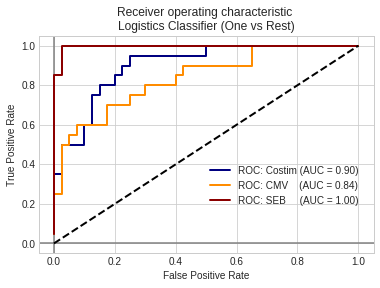

In [7]:
# Compute ROC curve and ROC area for each class
print("STEP: ROC curve")
print("+++++++++++++++++++++++++++++++++++")

### init
fpr, tpr, roc_auc = dict(), dict(), dict()
n_classes = len(dat_img.unique_label())

### get label: test data and predicted
res = pca_logreg.predict(dat_img_test)
y_prob = res['predicted_prob']
y_test = dat_img_test.label
y_test = to_categorical(y_test)

### calculate fpr and tpr
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

### Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

#######################################################

### set plot
plt.figure()
lw = 2

### since there is only two classes, below are the same
plt.plot(fpr[0], tpr[0], color='navy',       lw=lw, label='ROC: Costim (AUC = %0.2f)' % roc_auc[0])
plt.plot(fpr[1], tpr[1], color='darkorange', lw=lw, label='ROC: CMV    (AUC = %0.2f)' % roc_auc[1])
plt.plot(fpr[2], tpr[2], color='darkred',    lw=lw, label='ROC: SEB     (AUC = %0.2f)' % roc_auc[2])

### visualize ROC curve
plt.plot([0, 1], [0, 1], color='black', lw=lw, linestyle='--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.vlines(0, -0.05, 1.05, color = "Gray")
plt.hlines(0, -0.05, 1.05, color = "Gray")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic \nLogistics Classifier (One vs Rest)')
plt.legend(loc=(0.5, 0.2)) #plt.legend(loc="lower right")

plt.show()